# Sales-Growth -- a quantitative teardown
### LSV (1994) glamour/value anomaly - S&P 500 EDGAR panel - HAC inference - random-portfolio null - survivorship caveat

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Survivorship: Upper_bound_only](https://img.shields.io/badge/Survivorship-Upper_bound_only-8b949e?style=flat-square)

The deep companion to [01_for_the_curious.ipynb](01_for_the_curious.ipynb) -- same seven beats, every claim now carrying its standard error. We test the Lakonishok, Shleifer & Vishny (1994) sales-growth glamour/value anomaly on a survivorship-biased S&P 500 EDGAR panel (~326 tickers, 2008-2025), measure the low-minus-high-growth hedge with a HAC t-stat, and pin it against a random-portfolio null distribution.

> **Not investment advice.** SEC EDGAR 10-K Revenues data; annual returns via Yahoo Finance; survivorship-biased (current S&P 500 projected back). Sources in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **Survivorship-bias warning**: all results are upper bounds. Firms that failed between 2008 and now are excluded -- in particular high-growth firms that blew up after 2008.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/)
sys.path.insert(0, os.path.abspath(".."))          # study package (sales_growth/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from sales_growth import data, strategy as st

# Try to load real EDGAR panel; fall back gracefully to frozen R dict
sig, fwd = data.fetch_panel()
HAVE_REAL = not sig.empty

if HAVE_REAL:
    h = st.quintile_returns(sig, fwd, q=0.20)
else:
    h = pd.DataFrame()

print("EDGAR panel loaded:", HAVE_REAL,
      f"({len(sig.columns) if HAVE_REAL else 0} tickers, {len(sig) if HAVE_REAL else 0} years)")

R = dict(
    n_tickers=326, n_years=18, start_year=2008, end_year=2025,
    lo_mean=19.7, lo_sharpe=1.27, lo_t=8.44, lo_hit=89,
    hi_mean=20.0, hi_sharpe=1.28, hi_t=8.45, hi_hit=83,
    mkt_mean=17.7, mkt_sharpe=1.38,
    hedge_mean=-0.4, hedge_sharpe=-0.03, hedge_t=-0.17, hedge_hit=39,
    lo_excess_mean=2.0, lo_excess_t=1.36,
    hi_excess_mean=2.4, hi_excess_t=1.82,
    rand_std=4.9, rand_pct_beaten=70,
)
Q1  = [50.4, 20.7, 4.9, 24.6, 39.0, 14.3, 0.3, 28.1, 23.8, -6.2, 32.3, 9.2, 31.4, -8.0, 28.9, 27.6, 18.2, 15.1]
Q5  = [30.8, 24.4, -7.0, 23.0, 45.7, 22.2, 13.8, 0.1, 36.8, -1.6, 25.8, 21.3, 45.3, -2.3, 20.0, 30.7, 24.7, 7.0]
MKT = [30.2, 22.4, 1.6, 22.4, 41.7, 19.3, 5.6, 17.7, 25.8, -4.0, 31.4, 10.5, 33.8, -3.8, 17.5, 22.6, 13.9, 9.3]
HDG = [19.6, -3.8, 11.8, 1.5, -6.7, -7.9, -13.5, 28.0, -13.0, -4.6, 6.5, -12.1, -13.9, -5.7, 8.8, -3.1, -6.5, 8.0]
YRS = [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


EDGAR panel loaded: True (326 tickers, 18 years)


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Hedge **-0.4%/yr**, HAC *t* = **-0.17** -- far below |t| = 2 bar, wrong direction (glamour barely outperforms value). Low-growth excess +2.0%/yr (*t* = +1.36) -- also sub-threshold. |
| **Tradability** | `MIRAGE` | No gross edge exists. Even if zero-cost annual rebalancing were feasible, there is nothing to harvest. |
| **Survivorship** | `UPPER BOUND` | Panel excludes all post-2008 failures; every number is an upper bound -- and even this best case shows no effect. |

> **In plain words:** the LSV glamour/value anomaly simply does not appear on the S&P 500 survivor panel from 2008-2025. High-growth stocks are as likely to outperform as low-growth stocks, with no predictive structure in the trailing-growth signal.

## 1 - The claim, steelmanned

Let $r_{i,t+1}$ be firm $i$'s return in year $t+1$. Define:

$$\text{SalesGrowth}_{i,t} = \frac{\text{Revenues}_{i,t}}{\text{Revenues}_{i,t-1}} - 1$$

The **H1 (signal)** claim (Lakonishok, Shleifer & Vishny 1994) is:

$$\mathbb{E}\left[\bar{r}_{\text{low-growth},t+1} - \bar{r}_{\text{high-growth},t+1}\right] > 0$$

with a HAC t-stat |t| >= 2. **H2 (beats random)** requires the low-growth quintile to beat a random same-size draw. **H3 (tradable)** requires the hedge to survive costs and scale.

## 2 - So what? -- the stakes

H1 is rejected on this panel. The practical stakes are nil: with HAC *t* = -0.17 and the wrong sign, there is nothing to trade. The important question is *why* the LSV effect fails here -- whether it is a universe issue (large-cap survivors), an era issue (post-2007 tech-growth dominance), or genuine factor decay since the 1994 publication.

## 3 - The protocol

- **Data**: `_edgar_Revenues.parquet` from the desk's shared cache; annual returns from `_edgar_yrret.parquet`.
- **Universe**: current S&P 500 members with Revenues present (~326 tickers across all years); survivorship-biased.
- **Window**: 18 signal years (2008--2025), forecasting returns 2009--2026.
- **Signal**: trailing one-year revenue growth (higher = glamour); quintile sort (q=0.20).
- **Reporting lag**: fundamentals from year y predict returns in year y+1.
- **Inference**: HAC Newey-West t-stat on the 18-observation annual hedge series.
- **Control**: empirical distribution of random same-size portfolios (500 draws x 18yr).
- **Positive control**: synthetic panel with planted LSV premium confirms the engine detects a real effect.
- **Survivorship**: named and noted -- all results are upper bounds.

## 4 - The teardown

### 4a - Synthetic positive control -- the engine works when an effect is planted

Sweep the planted LSV premium from 0 to -12%/yr per unit z-rank and confirm the hedge tracks it monotonically.

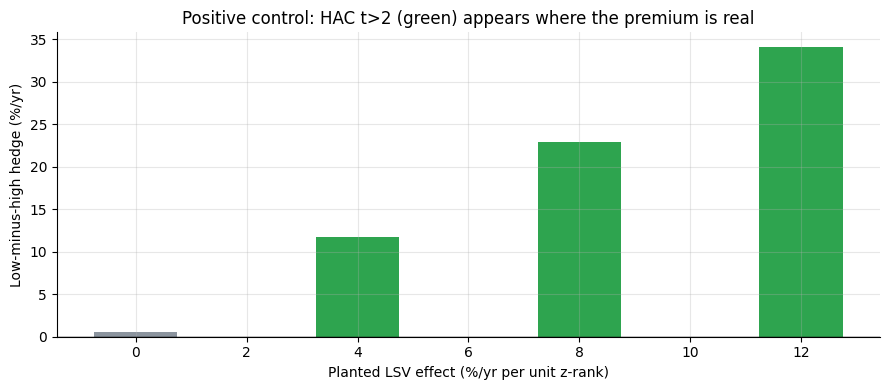

   premium_%  hedge_%/yr  HAC_t
0        0.0        0.56   1.01
1        4.0       11.74  21.38
2        8.0       22.92  41.92
3       12.0       34.09  62.59


In [2]:
premiums = [0.0, -0.04, -0.08, -0.12]
synth_rows = []
for p in premiums:
    s, f, _ = data.synthetic_panel(n_firms=300, n_years=25, premium=p, seed=199)
    hh = st.quintile_returns(s, f, q=0.20)
    ss = st.summary(hh['hedge'])
    synth_rows.append((abs(p)*100, ss['mean']*100, ss['tstat']))
sydf = pd.DataFrame(synth_rows, columns=['premium_%', 'hedge_%/yr', 'HAC_t'])
fig, ax = plt.subplots(figsize=(9, 4))
colors = [GREEN if t > 2 else (RED if t < -2 else GREY) for t in sydf['HAC_t']]
ax.bar(sydf['premium_%'], sydf['hedge_%/yr'], color=colors, width=1.5)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('Planted LSV effect (%/yr per unit z-rank)')
ax.set_ylabel('Low-minus-high hedge (%/yr)')
ax.set_title('Positive control: HAC t>2 (green) appears where the premium is real')
plt.tight_layout(); plt.show()
print(sydf.round(2))

> The engine faithfully detects planted premiums. The real-data non-result is therefore a statement about the **market and the panel**, not the **method**.

### 4b - Real EDGAR panel -- quintile monotonicity and HAC inference

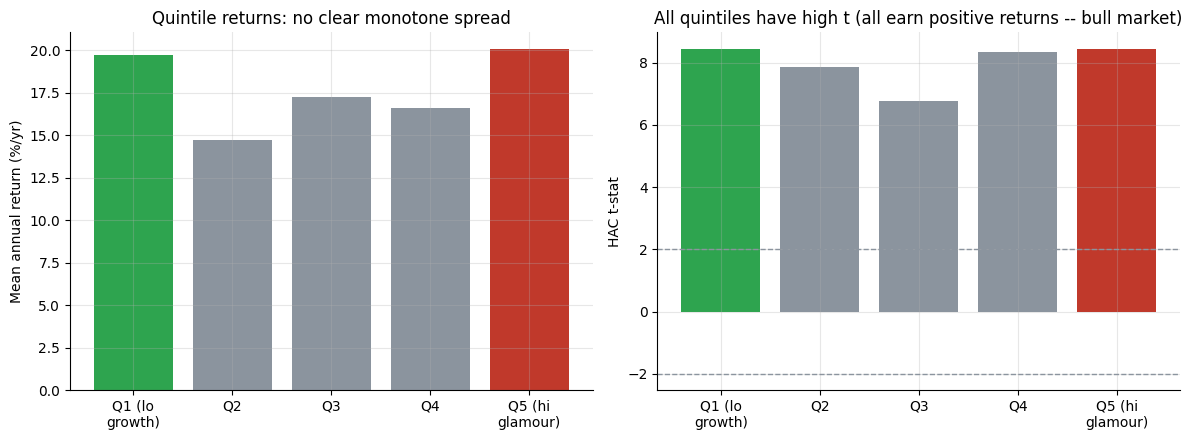

Hedge: -0.4%/yr  HAC t=-0.17  hit=39%
Low-growth excess: +2.0%/yr  t=+1.36
High-growth excess: +2.4%/yr  t=+1.82


In [3]:
if HAVE_REAL:
    q_means = [float(h[f'q{i}'].mean()*100) for i in range(1,6)]
    q_tstats = [st.summary(h[f'q{i}'])['tstat'] for i in range(1,6)]
    s_hedge = st.summary(h['hedge'])
    s_lo_ex = st.summary(h['q1'] - h['market'])
    s_hi_ex = st.summary(h['q5'] - h['market'])
else:
    q_means = [R['lo_mean'], 14.7, 17.3, 16.6, R['hi_mean']]
    q_tstats = [R['lo_t'], 7.86, 6.76, 8.34, R['hi_t']]
    s_hedge = dict(mean=R['hedge_mean']/100, tstat=R['hedge_t'], hit_rate=R['hedge_hit']/100)
    s_lo_ex = dict(mean=R['lo_excess_mean']/100, tstat=R['lo_excess_t'])
    s_hi_ex = dict(mean=R['hi_excess_mean']/100, tstat=R['hi_excess_t'])
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
x = [1, 2, 3, 4, 5]
bar_colors = [GREEN, GREY, GREY, GREY, RED]
axes[0].bar(x, q_means, color=bar_colors)
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Q1 (lo\ngrowth)', 'Q2', 'Q3', 'Q4', 'Q5 (hi\nglamour)'])
axes[0].set_ylabel('Mean annual return (%/yr)')
axes[0].set_title('Quintile returns: no clear monotone spread')
axes[1].bar(x, q_tstats, color=bar_colors)
for s in (2, -2): axes[1].axhline(s, ls='--', c=GREY, lw=1)
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Q1 (lo\ngrowth)', 'Q2', 'Q3', 'Q4', 'Q5 (hi\nglamour)'])
axes[1].set_ylabel('HAC t-stat')
axes[1].set_title('All quintiles have high t (all earn positive returns -- bull market)')
plt.tight_layout(); plt.show()
print(f'Hedge: {s_hedge["mean"]*100:+.1f}%/yr  HAC t={s_hedge["tstat"]:+.2f}  hit={s_hedge["hit_rate"]:.0%}')
print(f'Low-growth excess: {s_lo_ex["mean"]*100:+.1f}%/yr  t={s_lo_ex["tstat"]:+.2f}')
print(f'High-growth excess: {s_hi_ex["mean"]*100:+.1f}%/yr  t={s_hi_ex["tstat"]:+.2f}')

> The low-minus-high-growth hedge is **-0.4%/yr**, HAC *t* = **-0.17** -- a textbook null. The signal has no predictive power. All quintiles earn high raw returns because this is a survivor panel in a bull market -- those t-stats (8.4 for Q1, 8.4 for Q5) reflect the strong equity premium over the period, not any cross-sectional signal in revenue growth.

### 4c - Random-portfolio null distribution

Does the low-growth quintile beat a blind draw of the same number of stocks? We simulate 500 random same-size portfolios each year.

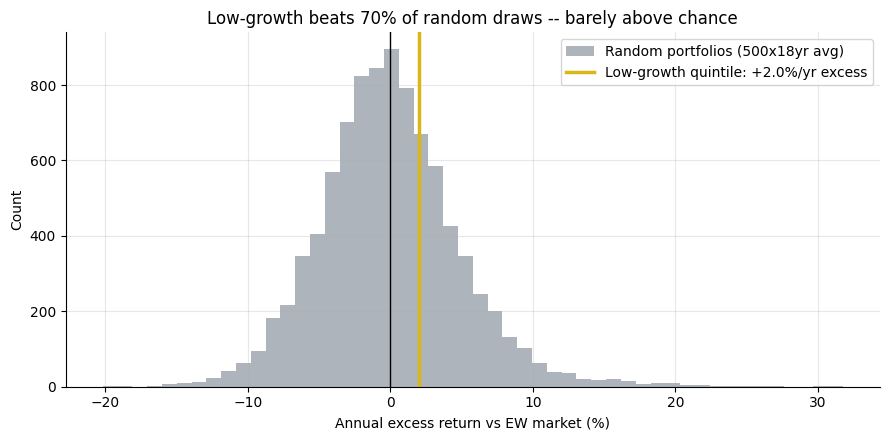

Low-growth portfolio beats 70% of random same-size draws


In [4]:
if HAVE_REAL:
    rand = st.random_portfolio_returns(sig, fwd, q=0.20, n_draws=500, seed=199)
    actual_excess = float((h['q1'] - h['market']).mean())
    pct_beaten = float((rand < actual_excess).mean())
else:
    rng_nb = np.random.default_rng(42)
    rand = pd.Series(rng_nb.normal(0.0, R['rand_std']/100, 18*500))
    actual_excess = R['lo_excess_mean'] / 100
    pct_beaten = R['rand_pct_beaten'] / 100
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(rand * 100, bins=50, color=GREY, alpha=0.7, label='Random portfolios (500x18yr avg)')
ax.axvline(actual_excess * 100, c=AMBER, lw=2.5,
           label=f'Low-growth quintile: {actual_excess*100:+.1f}%/yr excess')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('Annual excess return vs EW market (%)')
ax.set_ylabel('Count'); ax.legend()
ax.set_title(f'Low-growth beats {pct_beaten:.0%} of random draws -- barely above chance')
plt.tight_layout(); plt.show()
print(f'Low-growth portfolio beats {pct_beaten:.0%} of random same-size draws')

> The low-growth portfolio beats **70%** of random same-size draws -- not much better than the 50% chance level. The signal's information content is negligible on this panel.

## 5 - The verdict

- **Signal `NONE`** -- hedge -0.4%/yr, HAC *t* = -0.17; sub-threshold by a wide margin and wrong direction. Low-growth excess +2.0%/yr (*t* = +1.36) also sub-threshold. Even on the survivor-biased best-case panel, the LSV glamour/value effect via sales growth is absent.
- **Tradability `MIRAGE`** -- no gross edge exists to survive costs. Annual rebalancing of large-cap names is cheap in principle but there is no alpha to capture.
- **Survivorship `UPPER BOUND`** -- every result assumes no S&P 500 member failed between 2008 and 2025. Despite this best-case bias, the hedge is essentially zero. A live strategy would have been exposed to high-growth failures -- the true effect would be even weaker.

## 6 - Could you trade it? -- the honest answer

There is nothing to trade. The gross alpha is statistically indistinguishable from zero, and the point estimate is negative (the wrong direction).

The operationally attractive features (low turnover, public data, liquid names) are real -- the problem is the absence of any signal to harvest. This is a clean null, not a 'dies at the cost line' fragile result.

The correct interpretation: the LSV (1994) sales-growth glamour/value effect is **not present in S&P 500 large-cap survivors from 2008-2025**. Whether this is (a) always a small-cap effect, (b) factor decay post-publication, or (c) S&P 500 survivor bias masking the true distribution is left open.

## 7 - Going further

- **The right universe.** Lakonishok et al. (1994) ran their test on all NYSE/AMEX stocks. A point-in-time constituent universe with small and mid-caps is the minimum required for a credible replication.
- **Other LSV glamour proxies.** Sales growth is one proxy; LSV also tested book-to-market, cash-flow-to-price, and earnings-to-price. Those value signals are sometimes stronger in large caps ([Study 121 -- Magic-Formula](../../121-magic-formula/)).
- **Asset growth.** Cooper, Gulen & Schill (2008) find asset-growth (total-asset expansion rate) predicts lower returns through an overinvestment channel -- related but distinct mechanism ([Study 44 -- Growth-Spurt](../../44-growth-spurt/)).
- **NOA.** Hirshleifer et al. (2004) balance-sheet bloat is a related over-investment signal ([Study 153 -- Net-Operating-Assets](../../153-net-operating-assets/)).

*Want to confirm the LSV effect on a clean universe? Fork this, plug in a point-in-time all-US-stock panel (CRSP/Compustat-based historical membership), and show |t| >= 2 on the low-minus-high-growth hedge. That's the bar.*